In [ ]:
# Imports
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load the MNIST dataset
mnist_db = mnist.load_data()

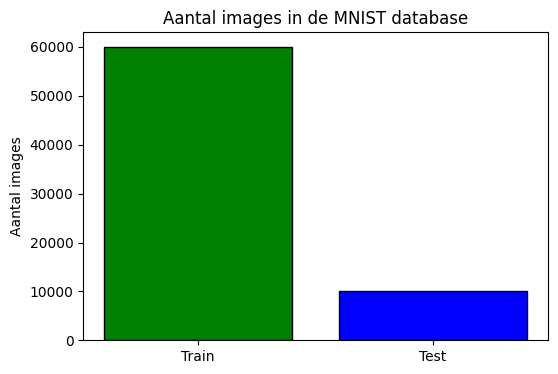

Totaal: 70000 images (60000 train, 10000 test)


In [5]:
# Visualisatie: aantal images in MNIST
(x_train, y_train), (x_test, y_test) = mnist_db
n_train, n_test = len(x_train), len(x_test)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Train', 'Test'], [n_train, n_test], color=['green', 'blue'], edgecolor='black')
ax.set_ylabel('Aantal images')
ax.set_title('Aantal images in de MNIST database')
plt.show()
print(f"Totaal: {n_train + n_test} images ({n_train} train, {n_test} test)")

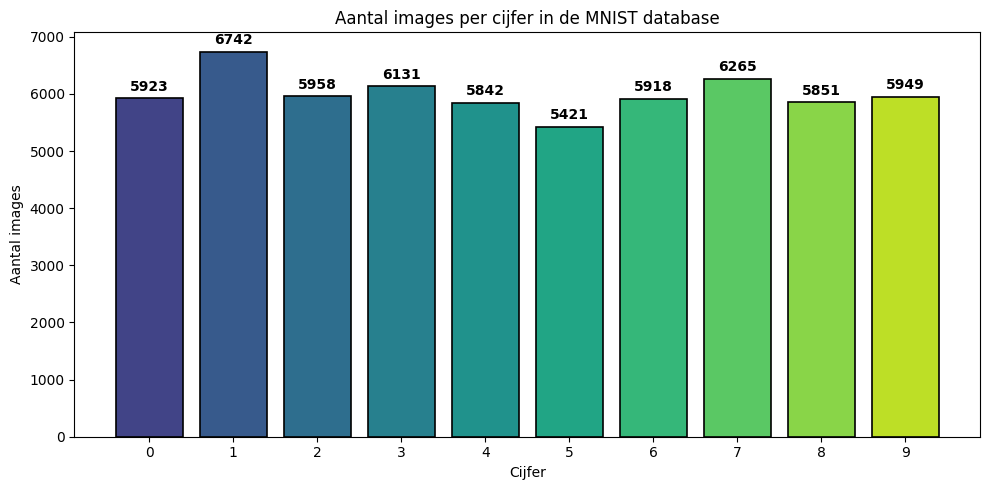

Totaal: 70000 images (60000 train, 10000 test)


In [6]:
# Visualize amount of images per number
digits, counts = np.unique(y_train, return_counts=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(digits)))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(digits, counts, color=colors, edgecolor='black', linewidth=1.2)

ax.set_xlabel('Cijfer')
ax.set_ylabel('Aantal images')
ax.set_title('Aantal images per cijfer in de MNIST database')
ax.set_xticks(digits)
ax.set_xticklabels(digits)

# Waarden bovenop de balken
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Totaal: {n_train + n_test} images ({n_train} train, {n_test} test)")

In [ ]:
# Check if the dataset is balanced
balanced = np.all(counts == counts[0])
print(f"Is de dataset gebalanceerd? {balanced}")

# Check which number has the most images
most_common = digits[np.argmax(counts)]
print("Meest voorkomende cijfer:", most_common)

# Check which number has the least images
least_common = digits[np.argmin(counts)]
print("Minst voorkomende cijfer:", least_common)


Is de dataset gebalanceerd? False
Meest voorkomende cijfer:  1
Minst voorkomende cijfer:  5


In [13]:
# Hoe groot is één afbeelding (vorm en datatype):
image_shape = x_train[0].shape
print("Afbeelding vorm:", image_shape)
print("Afbeelding datatype:", x_train[0].dtype.name)


Afbeelding vorm: (28, 28)
Afbeelding datatype: uint8


# Visuele analyse van cijfers

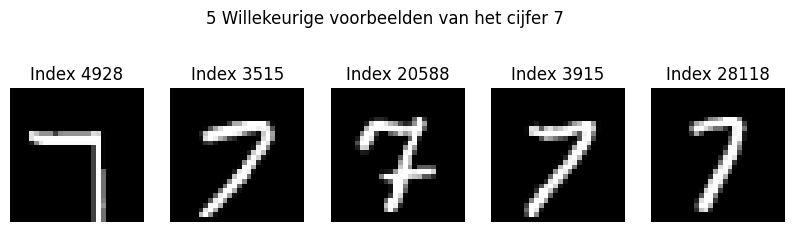

In [33]:
# 5 Willikeurige voorbeelden van het cijfer 7
indices_7 = np.where(y_train == 7)[0]
random_examples = np.random.choice(indices_7, 5, replace=False)

plt.figure(figsize=(10,3))
for i, idx in enumerate(random_examples):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.axis('off')
    plt.title(f"Index {idx}")
plt.suptitle("5 Willekeurige voorbeelden van het cijfer 7")
plt.show()

## Wat valt op?
1. Het lijkt veel op een 1.
2. Ik mis eigenlijk het standaard streepje in het midden.
3. Sommige 7's zijn veel dikker dan de andere.
4. Fotokwaliteit is erg laag.

## Vergelijking 1 en 7, 4 en 9

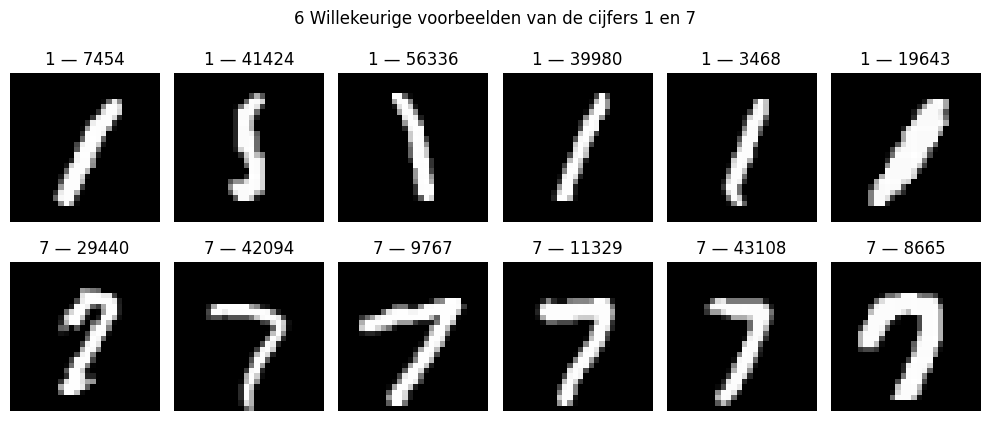

In [34]:
# Vergelijking 1 en 7
indices_1 = np.where(y_train == 1)[0]
indices_7 = np.where(y_train == 7)[0]

random_examples_7 = np.random.choice(indices_7, 6, replace=False)
random_examples_1 = np.random.choice(indices_1, 6, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(10, 4.5))
for i, idx in enumerate(random_examples_1):
    axes[0, i].imshow(x_train[idx], cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"1 — {idx}")
for i, idx in enumerate(random_examples_7):
    axes[1, i].imshow(x_train[idx], cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title(f"7 — {idx}")
fig.suptitle("6 Willekeurige voorbeelden van de cijfers 1 en 7")
plt.tight_layout()
plt.show()

### Vergelijking 1 en 7
#### Wat valt op?
1. 1 en 7 staan best ver van elkaar.
2. Verschil is duidelijk.
3. Soms is 1 gewoon een vlek.

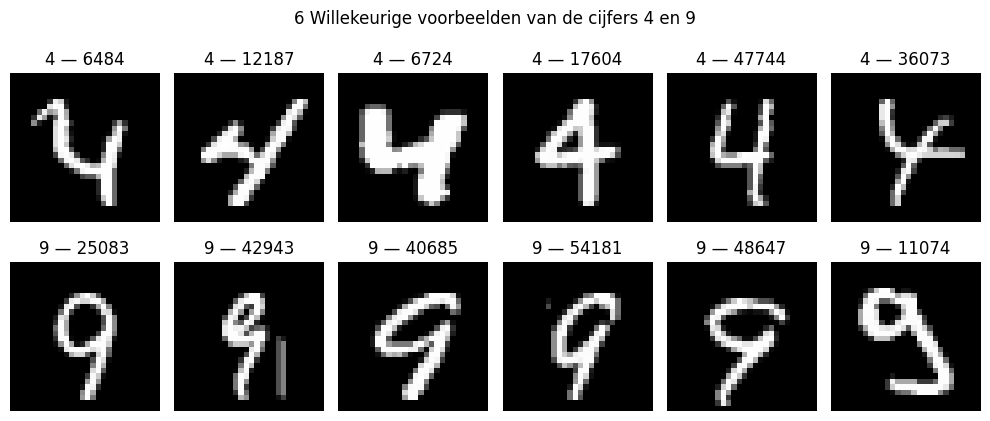

In [35]:
# Vergelijking 4 en 9
indices_4 = np.where(y_train == 4)[0]
indices_9 = np.where(y_train == 9)[0]

random_examples_4 = np.random.choice(indices_4, 6, replace=False)
random_examples_9 = np.random.choice(indices_9, 6, replace=False)

random_examples = np.concatenate((random_examples_4, random_examples_9))

fig, axes = plt.subplots(2, 6, figsize=(10, 4.5))
for i, idx in enumerate(random_examples_4):
    axes[0, i].imshow(x_train[idx], cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"4 — {idx}")
for i, idx in enumerate(random_examples_9):
    axes[1, i].imshow(x_train[idx], cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title(f"9 — {idx}")
fig.suptitle("6 Willekeurige voorbeelden van de cijfers 4 en 9")
plt.tight_layout()
plt.show()


### Vergelijking 4 en 9
#### Wat valt op?
1. 4 en 9 lijken ook minder op elkaar dan we dachten.
2. Verschil is duidelijk.
3. Voorbeeld 2 van 9 zou geinterpreteerd kunnen worden als een 4.

# Pixelstatistieken

Gemiddelde pixel waarde: 33.318421449829934
Gemiddelde pixel waarde van het cijfer 8: 38.28977538289286
De lichtste pixel is de pixel met index 407
De donkerste pixel is de pixel met index 0


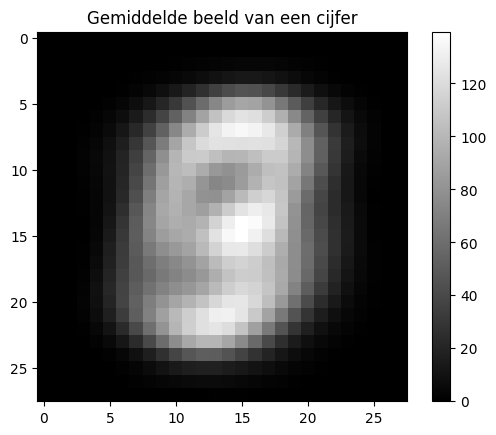

In [37]:
# Wat is de gemiddelde pixel waarde van alle afbeeldingen samen:
gemiddelde_pixel_waarde = np.mean(x_train)
print(f"Gemiddelde pixel waarde: {gemiddelde_pixel_waarde}")
# Wat is de gemiddelde pixel waarde van het cijfer 8:
gemiddelde_pixel_waarde_8 = np.mean(x_train[y_train == 8])
print(f"Gemiddelde pixel waarde van het cijfer 8: {gemiddelde_pixel_waarde_8}")
# Welke pixel is gemiddeld het lichtst:
lichtste_pixel = np.argmax(np.mean(x_train, axis=0))
print(f"De lichtste pixel is de pixel met index {lichtste_pixel}")
# Welke pixel is gemiddeld het donkerst:
donkerste_pixel = np.argmin(np.mean(x_train, axis=0))
print(f"De donkerste pixel is de pixel met index {donkerste_pixel}")
# Wat is het gemiddelde beeld van een cijfer:
gemiddelde_beeld = np.mean(x_train, axis=0)
plt.imshow(gemiddelde_beeld.reshape(28, 28), cmap='gray')
plt.colorbar()
plt.title('Gemiddelde beeld van een cijfer')
plt.show()
# Wat is het gemiddelde beeld van een cijfer 8:
gemiddelde_beeld_8 = np.mean(x_train[y_train == 8], axis=0)
